In [261]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from sklearn.preprocessing import MinMaxScaler
import math as ma
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [262]:
connect = sqlite3.connect("C:/Forge/Python/database.db")
df = pd.read_sql('SELECT * FROM weather5', connect)
connect.close()

In [263]:
def get_label_list(df, flag_print):
    label_list = df.columns.tolist() 
    for i in range(len(label_list)):
        df[label_list[i]] = pd.to_numeric(df[label_list[i]], errors='coerce') # заменяем пропуски на NaN
        if (flag_print):
            print(i, "/", i - len(label_list), ": ", label_list[i], sep="", end="  ")
    return label_list

label_list = get_label_list(df, 1)
    
df.head(-1)

0/-9: id  1/-8: year  2/-7: month  3/-6: day  4/-5: max_temp  5/-4: sr_temp  6/-3: min_temp  7/-2: precipit  8/-1: norm_plus  

,id,year,month,day,max_temp,sr_temp,min_temp,precipit,norm_plus
0,1,1881,1,1,1.0,-0.2,-1.5,1.3,6.5
1,2,1881,1,2,1.7,-1.1,-2.5,0.1,5.8
2,3,1881,1,3,1.9,1.1,-0.9,0.0,8.1
3,4,1881,1,4,2.2,1.7,0.7,0.4,8.8
4,5,1881,1,5,2.2,-6.1,-10.4,0.0,1.1
...,...,...,...,...,...,...,...,...,...
53297,53298,2026,8,15,18.8,16.1,13.5,5.0,-1.6
53298,53299,2026,8,16,22.3,18.1,14.7,1.0,0.6
53299,53300,2026,8,17,19.5,17.1,15.1,0.4,-0.3
53300,53301,2026,8,18,20.0,16.8,14.6,6.5,-0.5


In [264]:
mode = 1

In [265]:
if mode == 1:
    for i in range(len(label_list)):
        df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
    df = df.dropna()
elif mode == 2:
    # Создаём словарь средних значений
    fill_values = {col: df[col].mean() for col in label_list}

    # Заполняем пропуски во всех столбцах за один вызов
    df.fillna(fill_values, inplace=True)

df.head(-1)

,id,year,month,day,max_temp,sr_temp,min_temp,precipit,norm_plus
0,1,1881,1,1,1.0,-0.2,-1.5,1.3,6.5
1,2,1881,1,2,1.7,-1.1,-2.5,0.1,5.8
2,3,1881,1,3,1.9,1.1,-0.9,0.0,8.1
3,4,1881,1,4,2.2,1.7,0.7,0.4,8.8
4,5,1881,1,5,2.2,-6.1,-10.4,0.0,1.1
...,...,...,...,...,...,...,...,...,...
53297,53298,2026,8,15,18.8,16.1,13.5,5.0,-1.6
53298,53299,2026,8,16,22.3,18.1,14.7,1.0,0.6
53299,53300,2026,8,17,19.5,17.1,15.1,0.4,-0.3
53300,53301,2026,8,18,20.0,16.8,14.6,6.5,-0.5


In [266]:
df['year'] = df['year'].shift(-1)
df['month'] = df['month'].shift(-1)
df['day'] = df['day'].shift(-1)
df['sr_temp'] = df['sr_temp'].shift(-1)
df['ras_temp'] = df['max_temp'] - df['min_temp']
del df['min_temp']
del df['max_temp']
label_list = get_label_list(df, 1)
df.head(-1)

0/-8: id  1/-7: year  2/-6: month  3/-5: day  4/-4: sr_temp  5/-3: precipit  6/-2: norm_plus  7/-1: ras_temp  

,id,year,month,day,sr_temp,precipit,norm_plus,ras_temp
0,1,1881.0,1.0,2.0,-1.1,1.3,6.5,2.5
1,2,1881.0,1.0,3.0,1.1,0.1,5.8,4.2
2,3,1881.0,1.0,4.0,1.7,0.0,8.1,2.8
3,4,1881.0,1.0,5.0,-6.1,0.4,8.8,1.5
4,5,1881.0,1.0,6.0,-7.6,0.0,1.1,12.6
...,...,...,...,...,...,...,...,...
53297,53298,2026.0,8.0,16.0,18.1,5.0,-1.6,5.3
53298,53299,2026.0,8.0,17.0,17.1,1.0,0.6,7.6
53299,53300,2026.0,8.0,18.0,16.8,0.4,-0.3,4.4
53300,53301,2026.0,8.0,19.0,14.1,6.5,-0.5,5.4


In [267]:
days_in_month_1 = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце не весокостного года
days_in_month_2 = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] # количество дней в каждом месяце весокостного года

def day_of_year(x):                                                                 # 
    try:                                                                            #
        if x['year'] == 400 or x['year'] % 4 == 0 and x['year'] % 100 != 0:         # 
            return sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         # функция возвращающая номер дня в году
        else:                                                                       #
            return sum(days_in_month_1[:int(x['month'])-1]) + int(x['day'])         #
    except:                                                                         #
        pass                                                                        #

df['day_of_year'] = df[['year', 'month', 'day']].apply(day_of_year, axis=1)

scal = MinMaxScaler()
df['month'] = scal.fit_transform(df[['month']]) * 2 * ma.pi   # преобразуем номер месяца в соответствующее количество радиан, где 12-ый месяц = 6.28 радиан
df['day'] = scal.fit_transform(df[['day']]) * 2 * ma.pi        # преобразуем номер дня в месяце в соответствующее количество радиан, где последний день месяца = 6.28 радиан
df['day_of_year'] = scal.fit_transform(df[['day_of_year']]) * 2 * ma.pi    # преобразуем номер дня в году в соответствующее количество радиан, где 365 день = 6.28 радиан
def set_rad_cos(x):
    return ma.cos(x)
def set_rad_sin(x):
    return ma.sin(x)

df['month_cos'] = df['month'].apply(set_rad_cos)
df['month_sin'] = df['month'].apply(set_rad_sin)

df['day_cos'] = df['day'].apply(set_rad_cos)
df['day_sin'] = df['day'].apply(set_rad_sin)

df['day_of_year_cos'] = df['day_of_year'].apply(set_rad_cos)
df['day_of_year_sin'] = df['day_of_year'].apply(set_rad_sin)

df = df.drop(['id', 'day_of_year', 'month', 'day'], axis=1)         # убираем все ненужные колонки датасета
# df = df.drop(['id'], axis=1)

label_list = get_label_list(df, 1)
print()
df.head(-1)

0/-11: year  1/-10: sr_temp  2/-9: precipit  3/-8: norm_plus  4/-7: ras_temp  5/-6: month_cos  6/-5: month_sin  7/-4: day_cos  8/-3: day_sin  9/-2: day_of_year_cos  10/-1: day_of_year_sin  


,year,sr_temp,precipit,norm_plus,ras_temp,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
0,1881.0,-1.1,1.3,6.5,2.5,1.000000,0.00000,0.978148,2.079117e-01,0.999851,0.017261
1,1881.0,1.1,0.1,5.8,4.2,1.000000,0.00000,0.913545,4.067366e-01,0.999404,0.034516
2,1881.0,1.7,0.0,8.1,2.8,1.000000,0.00000,0.809017,5.877853e-01,0.998659,0.051761
3,1881.0,-6.1,0.4,8.8,1.5,1.000000,0.00000,0.669131,7.431448e-01,0.997617,0.068991
4,1881.0,-7.6,0.0,1.1,12.6,1.000000,0.00000,0.500000,8.660254e-01,0.996278,0.086200
...,...,...,...,...,...,...,...,...,...,...,...
53297,2026.0,18.1,5.0,-1.6,5.3,-0.654861,-0.75575,-1.000000,1.224647e-16,-0.713183,-0.700978
53298,2026.0,17.1,1.0,0.6,7.6,-0.654861,-0.75575,-0.978148,-2.079117e-01,-0.700978,-0.713183
53299,2026.0,16.8,0.4,-0.3,4.4,-0.654861,-0.75575,-0.913545,-4.067366e-01,-0.688563,-0.725176
53300,2026.0,14.1,6.5,-0.5,5.4,-0.654861,-0.75575,-0.809017,-5.877853e-01,-0.675944,-0.736953


In [268]:
x = pd.DataFrame(df.copy().iloc[:, [0, 2, 4, 5, 6, 7, 8, 9, 10]])
y = pd.DataFrame(df.copy().iloc[:, [1]])

label_list = x.columns.tolist()

x.dropna(inplace=True)
y.dropna(inplace=True)

print("Date_of_work:")
print(x, y)

Date_of_work:
         year  precipit  ras_temp  month_cos  month_sin   day_cos  \
0      1881.0       1.3       2.5   1.000000    0.00000  0.978148   
1      1881.0       0.1       4.2   1.000000    0.00000  0.913545   
2      1881.0       0.0       2.8   1.000000    0.00000  0.809017   
3      1881.0       0.4       1.5   1.000000    0.00000  0.669131   
4      1881.0       0.0      12.6   1.000000    0.00000  0.500000   
...       ...       ...       ...        ...        ...       ...   
53297  2026.0       5.0       5.3  -0.654861   -0.75575 -1.000000   
53298  2026.0       1.0       7.6  -0.654861   -0.75575 -0.978148   
53299  2026.0       0.4       4.4  -0.654861   -0.75575 -0.913545   
53300  2026.0       6.5       5.4  -0.654861   -0.75575 -0.809017   
53301  2026.0      34.0       3.8  -0.654861   -0.75575 -0.669131   

            day_sin  day_of_year_cos  day_of_year_sin  
0      2.079117e-01         0.999851         0.017261  
1      4.067366e-01         0.999404         

In [269]:
x.head(1) # то от чего предсказывается

,year,precipit,ras_temp,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin
0,1881.0,1.3,2.5,1.0,0.0,0.978148,0.207912,0.999851,0.017261


In [270]:
y.head(1) # то что предсказывается

,sr_temp
0,-1.1


In [271]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state = 0)
print(x_test)

         year  precipit  ras_temp  month_cos  month_sin   day_cos  \
23170  1944.0       1.0       5.5  -0.142315   0.989821 -0.104528   
36004  1979.0       0.0       8.3  -0.654861   0.755750 -0.978148   
45409  2005.0       2.2       4.9   1.000000   0.000000  0.669131   
48759  2014.0       0.0       3.9   0.415415   0.909632 -0.104528   
42317  1996.0       0.0      12.2  -0.654861  -0.755750 -1.000000   
...       ...       ...       ...        ...        ...       ...   
2754   1888.0       0.0       4.5  -0.959493  -0.281733 -0.669131   
8868   1905.0       0.2       3.4   0.415415   0.909632  0.500000   
1913   1886.0       1.2      11.9   0.415415   0.909632  0.309017   
30184  1963.0       0.0       9.7  -0.959493   0.281733 -0.309017   
36872  1981.0       0.0       9.0  -0.142315  -0.989821  0.978148   

            day_sin  day_of_year_cos  day_of_year_sin  
23170 -9.945219e-01        -0.354605         0.935016  
36004 -2.079117e-01        -0.700978         0.713183  
454

In [272]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=10, max_features=5)
model.fit(x_train,y_train)

y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

df['Real'] = df['sr_temp']
y_pred_df = pd.DataFrame({'Predicted': y_pred_test}, index=y_test.index)
df = df.join(y_pred_df, how='left')
df.head(-1)

c:\Users\ivanh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,year,sr_temp,precipit,norm_plus,ras_temp,month_cos,month_sin,day_cos,day_sin,day_of_year_cos,day_of_year_sin,Real,Predicted
0,1881.0,-1.1,1.3,6.5,2.5,1.000000,0.00000,0.978148,2.079117e-01,0.999851,0.017261,-1.1,-5.191935
1,1881.0,1.1,0.1,5.8,4.2,1.000000,0.00000,0.913545,4.067366e-01,0.999404,0.034516,1.1,NaN
2,1881.0,1.7,0.0,8.1,2.8,1.000000,0.00000,0.809017,5.877853e-01,0.998659,0.051761,1.7,NaN
3,1881.0,-6.1,0.4,8.8,1.5,1.000000,0.00000,0.669131,7.431448e-01,0.997617,0.068991,-6.1,NaN
4,1881.0,-7.6,0.0,1.1,12.6,1.000000,0.00000,0.500000,8.660254e-01,0.996278,0.086200,-7.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53297,2026.0,18.1,5.0,-1.6,5.3,-0.654861,-0.75575,-1.000000,1.224647e-16,-0.713183,-0.700978,18.1,NaN
53298,2026.0,17.1,1.0,0.6,7.6,-0.654861,-0.75575,-0.978148,-2.079117e-01,-0.700978,-0.713183,17.1,NaN
53299,2026.0,16.8,0.4,-0.3,4.4,-0.654861,-0.75575,-0.913545,-4.067366e-01,-0.688563,-0.725176,16.8,16.901953
53300,2026.0,14.1,6.5,-0.5,5.4,-0.654861,-0.75575,-0.809017,-5.877853e-01,-0.675944,-0.736953,14.1,16.828378


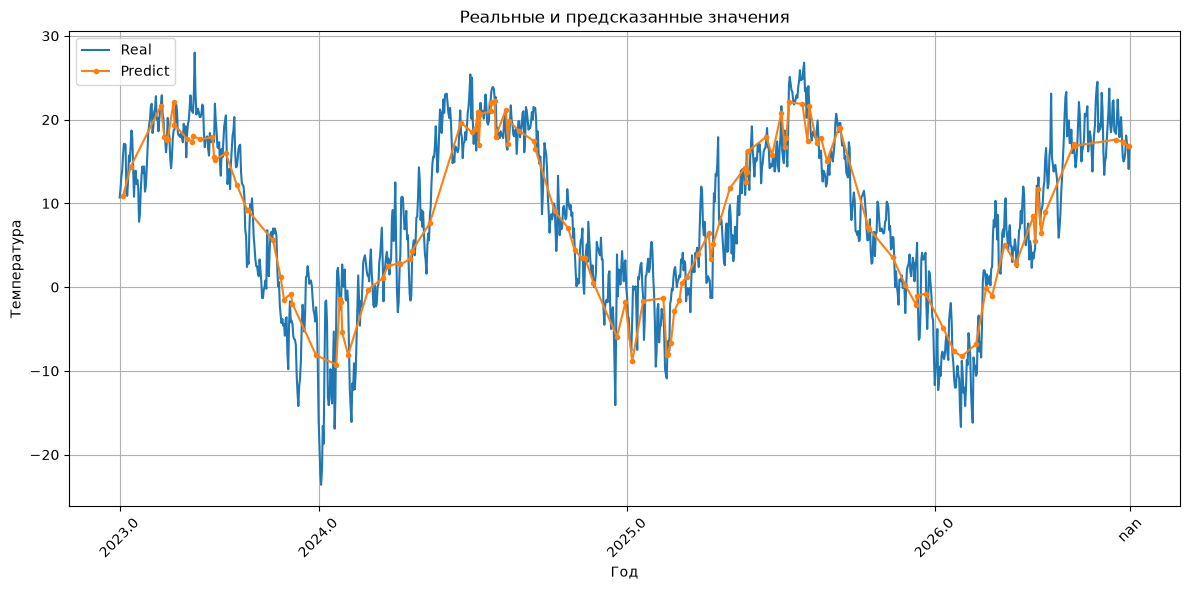

feature_importances:
       year  precipit  ras_temp  month_cos  month_sin  day_cos   day_sin  \
0  0.019149  0.008486   0.03948   0.254426   0.080774  0.00234  0.002514   

   day_of_year_cos  day_of_year_sin  
0         0.454907         0.137923  
------------------------
# MAE и MSE по обучающей выборке
Train MSE:  14.396736251793063
Train MAE:  2.8879650246128272
------------------------
# MAE и MSE по тестовой выборке
Test MSE:  16.086097945906427
Test MAE:  3.059024295389742
------------------------
R^2: 0.842571288948118


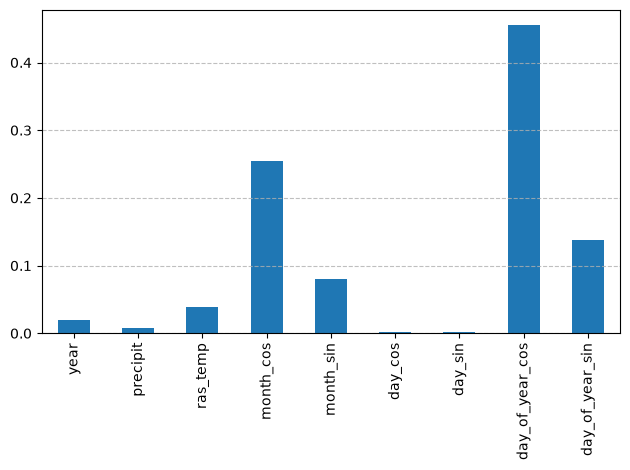

In [273]:
deep = 1200

df_tail = df[-deep:].copy()
real_vals = df_tail['sr_temp'].values
pred_vals = df_tail['Predicted'].values

x_indexes = range(len(real_vals))

plt.figure(figsize=(12, 6))
plt.plot(x_indexes, real_vals, label='Real')
pred_mask = ~pd.isna(pred_vals)

pred_x, pred_y = [], []
for i in range(len(pred_vals)):
    if pred_mask[i]:
        pred_x.append(i)
        pred_y.append(pred_vals[i])

plt.plot(pred_x, pred_y, label='Predict', marker='o', markersize=3)

years = df_tail['year'].values
change_points = [0]
for i in range(1, len(years)):
    if years[i] != years[i-1]:
        change_points.append(i)

tick_positions = change_points
tick_labels = [str(years[pos]) for pos in change_points]

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.xlabel('Год')
plt.ylabel('Температура')
plt.title('Реальные и предсказанные значения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


label_list = pd.DataFrame(x_test).columns.tolist()

m = model.feature_importances_
cof = pd.DataFrame()
for i in range(len(label_list)):
    cof[label_list[i]] = [m[i]]
print('feature_importances:')
print(cof)
df_tail = df.dropna()

print("------------------------")
print("# MAE и MSE по обучающей выборке")
print("Train MSE: ", mean_squared_error(y_train, y_pred_train))
print("Train MAE: ", mean_absolute_error(y_train, y_pred_train))

print("------------------------")
print("# MAE и MSE по тестовой выборке")
print("Test MSE: ", mean_squared_error(df_tail['Real'], df_tail['Predicted']))
print("Test MAE: ", mean_absolute_error(df_tail['Real'], df_tail['Predicted']))

print("------------------------")
r = r2_score(df_tail['Real'], df_tail['Predicted'])
n = len(df)
p = len(label_list)
print("R^2:", r)

coef_col_par = pd.DataFrame({
    "Параметр": [label_list],
    "коэффициент": [model.feature_importances_]})

cof.iloc[0].plot(kind='bar')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()